In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [10]:
## Step 1: Load and Preprocess Data
# Load training and test datasets
df_train = pd.read_csv('/content/trainset.csv')
df_test = pd.read_csv('/content/testset.csv')

In [11]:
print('Files in My Drive:')
!ls -F '/content/drive/MyDrive/'

Files in My Drive:
'Colab Notebooks'/
 com.feralinteractive.gridautosport_edition_android/
 customers.csv
'Deep learning.gsheet'
'DL- Ex-2.ipynb'
'EX-1-Regression model.ipynb'
'IMG-20260516-WA0017 (1).jpg'
 IMG-20260516-WA0017.jpg
 IMG-20260516-WA0018.jpg
 IMG-20260516-WA0019.jpg
 IMG-20260516-WA0020.jpg
'Screenshot 2026-04-25 121058.png'
'Screenshot 2026-04-25 121203.png'
'Screenshot 2026-05-16 135719.png'
'Screenshot 2026-05-16 135850.png'
'Screenshot 2026-05-16 140006.png'
'Screenshot 2026-05-16 140125.png'


In [7]:
print('Files in My Drive and its subfolders:')
!find '/content/drive/MyDrive/' -print

Files in My Drive and its subfolders:
/content/drive/MyDrive/
/content/drive/MyDrive/Colab Notebooks
/content/drive/MyDrive/Colab Notebooks/stockprice_Exp (1).ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled1.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled2.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled3.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled4.ipynb
/content/drive/MyDrive/Colab Notebooks/DL EX 2.ipynb
/content/drive/MyDrive/Colab Notebooks/Copy of DL- Ex-2 (1).ipynb
/content/drive/MyDrive/Colab Notebooks/DL- Ex-2.ipynb
/content/drive/MyDrive/Colab Notebooks/Copy of DL- Ex-2.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled5.ipynb
/content/drive/MyDrive/Colab Notebooks/DL-EXP-3.ipynb
/content/drive/MyDrive/Colab Notebooks/Copy of DL-EXP-3.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled6.ipynb
/content/drive/MyDrive/Colab Notebooks/EX_4.ipynb
/content/drive/MyDrive/Colab Notebooks/Copy of EX

In [12]:
# Use closing prices
train_prices = df_train['Close'].values.reshape(-1, 1)
test_prices = df_test['Close'].values.reshape(-1, 1)

In [13]:
# Normalize the data based on training set only
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train_prices)
scaled_test = scaler.transform(test_prices)

In [14]:
# Create sequences
def create_sequences(data, seq_length):
    x = []
    y = []
    for i in range(len(data) - seq_length):
        x.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(x), np.array(y)

seq_length = 60
x_train, y_train = create_sequences(scaled_train, seq_length)
x_test, y_test = create_sequences(scaled_test, seq_length)


In [15]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((1199, 60, 1), (1199, 1), (65, 60, 1), (65, 1))

In [16]:
# Convert to PyTorch tensors
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)


In [17]:
# Create dataset and dataloader
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [19]:
##Step 2: Define RNN Model

class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super(RNNModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Initialize hidden state with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # Pass through RNN layer
        out, _ = self.rnn(x, h0)

        # Take the output from the last time step
        out = self.fc(out[:, -1, :])
        return out

In [20]:
model = RNNModel()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [21]:
!pip install torchinfo

In [22]:
from torchinfo import summary

# input_size = (batch_size, seq_len, input_size)
summary(model, input_size=(64, 60, 1))

Layer (type:depth-idx)                   Output Shape              Param #
RNNModel                                 [64, 1]                   --
├─RNN: 1-1                               [64, 60, 64]              12,608
├─Linear: 1-2                            [64, 1]                   65
Total params: 12,673
Trainable params: 12,673
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 48.42
Input size (MB): 0.02
Forward/backward pass size (MB): 1.97
Params size (MB): 0.05
Estimated Total Size (MB): 2.03

In [23]:
criterion =nn.MSELoss()
optimizer =torch.optim.Adam(model.parameters(),lr=0.001)

In [31]:
def train_model(model, train_loader, criterion, optimizer, epochs=20):
    train_losses = []
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        train_losses.append(total_loss / len(train_loader))
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss / len(train_loader):.4f}")
    return train_losses

# Call the train_model function to start training
train_losses = train_model(model, train_loader, criterion, optimizer, epochs=20)

Epoch [1/20], Loss: 0.0610
Epoch [2/20], Loss: 0.0132
Epoch [3/20], Loss: 0.0014
Epoch [4/20], Loss: 0.0007
Epoch [5/20], Loss: 0.0005
Epoch [6/20], Loss: 0.0004
Epoch [7/20], Loss: 0.0004
Epoch [8/20], Loss: 0.0004
Epoch [9/20], Loss: 0.0004
Epoch [10/20], Loss: 0.0004
Epoch [11/20], Loss: 0.0004
Epoch [12/20], Loss: 0.0003
Epoch [13/20], Loss: 0.0004
Epoch [14/20], Loss: 0.0004
Epoch [15/20], Loss: 0.0004
Epoch [16/20], Loss: 0.0003
Epoch [17/20], Loss: 0.0003
Epoch [18/20], Loss: 0.0003
Epoch [19/20], Loss: 0.0003
Epoch [20/20], Loss: 0.0003


Name: Jagan J P
Register Number:212224230099


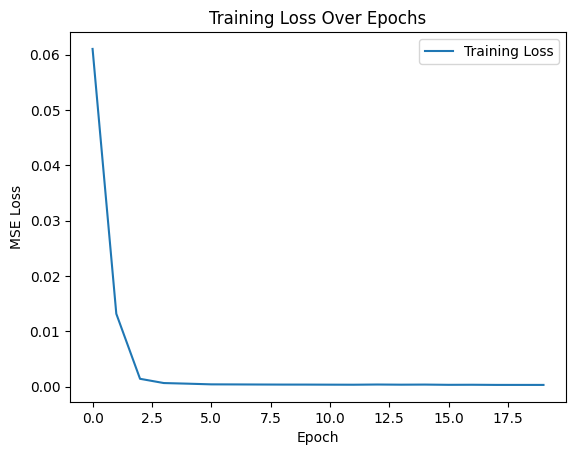

In [32]:
# Plot training loss
print('Name: Jagan J P')
print('Register Number:212224230099')
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.show()

Name:Jagan J P
Register Number:212224230099


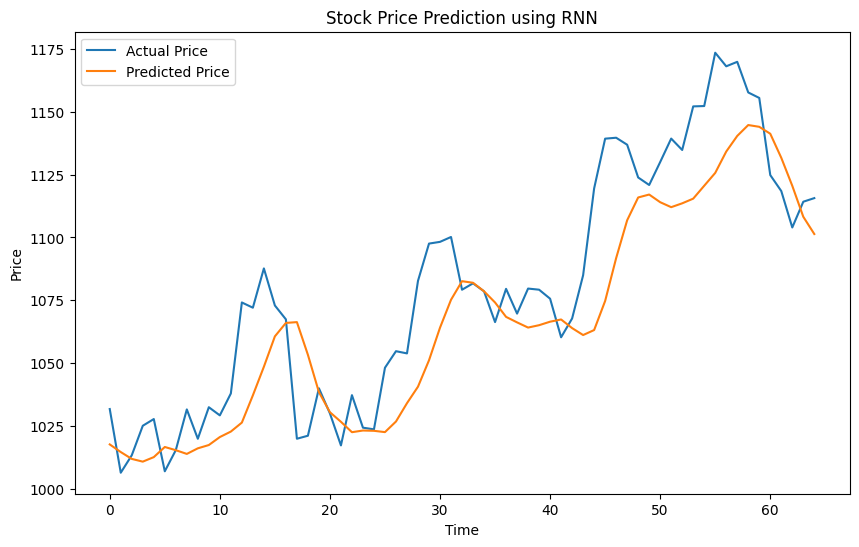

Predicted Price: [1101.3729]
Actual Price: [1115.65]


In [33]:
## Step 4: Make Predictions on Test Set
model.eval()
with torch.no_grad():
    predicted = model(x_test_tensor.to(device)).cpu().numpy()
    actual = y_test_tensor.cpu().numpy()

# Inverse transform the predictions and actual values
predicted_prices = scaler.inverse_transform(predicted)
actual_prices = scaler.inverse_transform(actual)

# Plot the predictions vs actual prices
print('Name:Jagan J P')
print('Register Number:212224230099')
plt.figure(figsize=(10, 6))
plt.plot(actual_prices, label='Actual Price')
plt.plot(predicted_prices, label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Stock Price Prediction using RNN')
plt.legend()
plt.show()
print(f'Predicted Price: {predicted_prices[-1]}')
print(f'Actual Price: {actual_prices[-1]}')